In [1]:
import pandas as pd
import warnings
import os
from codecarbon import EmissionsTracker

# Standard configuration
warnings.filterwarnings('ignore')

# Carbon footprint tracking initialization
tracker = EmissionsTracker(
    log_level="error", 
    save_to_file=True, 
    output_dir=".", 
    output_file="emissions_eda.csv"
)

tracker.start()

# Data ingestion
df = pd.read_csv('HRDataset_v14.csv')

# Feature suppression and generalization for privacy compliance 
# Removing Personally Identifiable Informationand sensitive identifiers
df_anon = df.drop(columns=['Employee_Name', 'EmpID', 'ManagerName', 'Zip'])

# Date of Birth generalization: keeping only the year to reduce re-identification risk
df_anon['DOB'] = pd.to_datetime(df_anon['DOB'], errors='coerce').dt.year

print("Anonymization phase completed successfully.")

[codecarbon WARNING @ 09:39:38] Multiple instances of codecarbon are allowed to run at the same time.


Anonymization phase completed successfully.


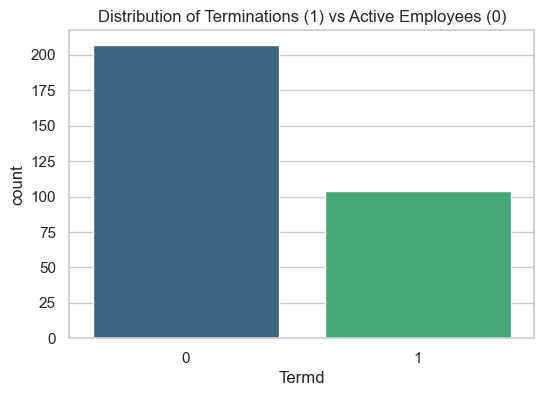

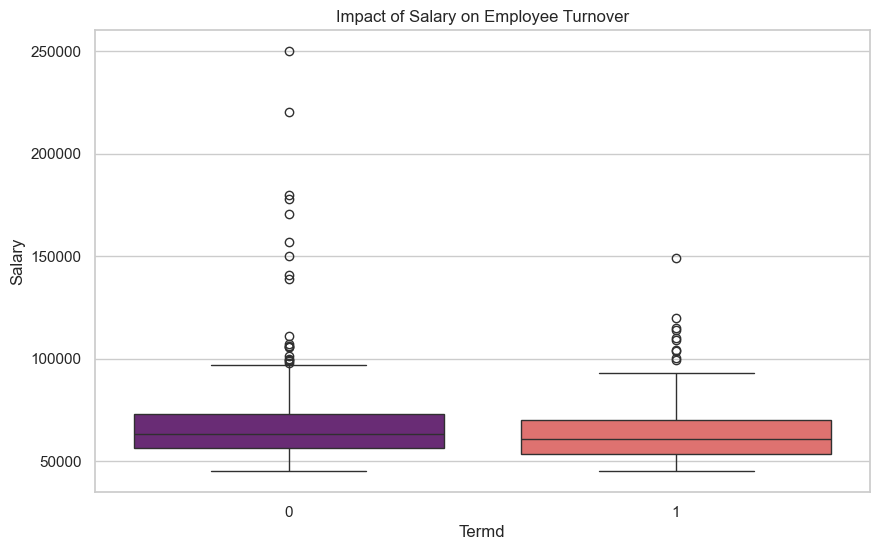

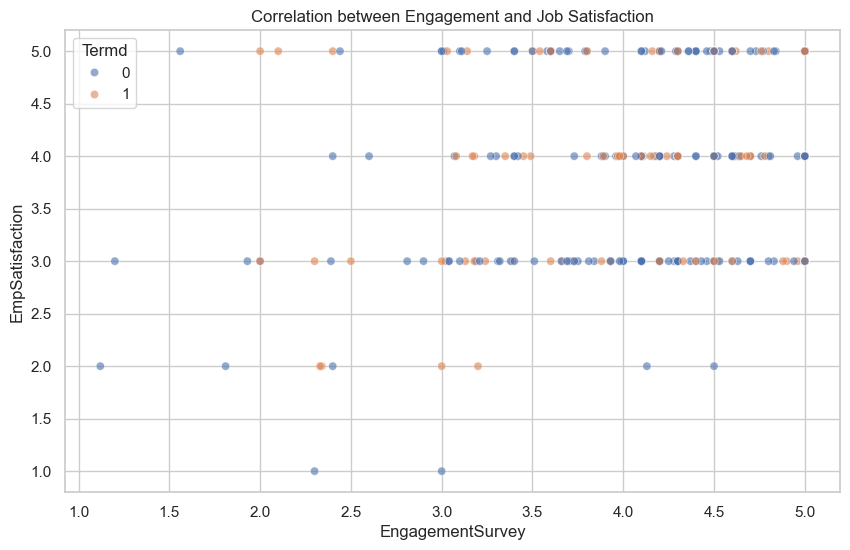

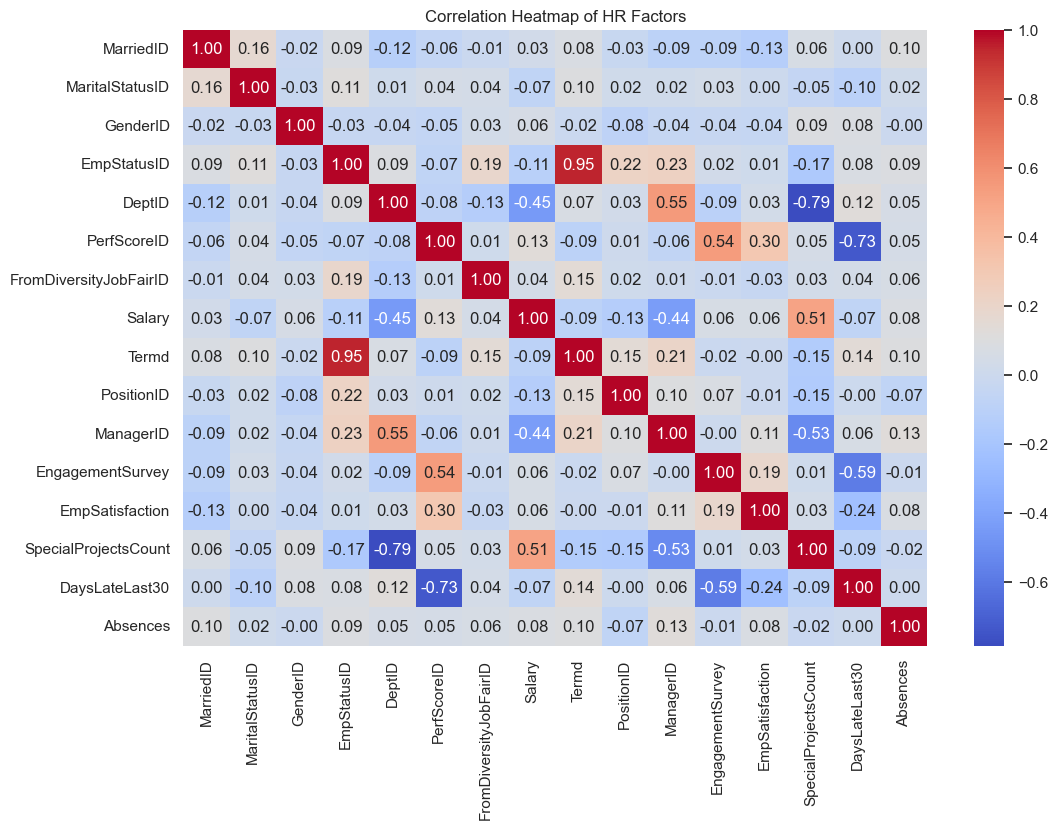

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualization configuration
sns.set(style="whitegrid")

# Target variable distribution analysis (Termd: 1 = Terminated, 0 = Active)
plt.figure(figsize=(6, 4))
sns.countplot(data=df_anon, x='Termd', palette='viridis')
plt.title('Distribution of Terminations (1) vs Active Employees (0)')
plt.savefig('distribution_turnover.png')

# Statistical relationship between Salary and Turnover
# Boxplot to identify distribution shifts and potential outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_anon, x='Termd', y='Salary', palette='magma')
plt.title('Impact of Salary on Employee Turnover')
plt.savefig('salary_vs_turnover.png')

# Bi-variate analysis: Satisfaction vs Engagement levels
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_anon, x='EngagementSurvey', y='EmpSatisfaction', hue='Termd', alpha=0.6)
plt.title('Correlation between Engagement and Job Satisfaction')
plt.savefig('satisfaction_scatter.png')

# Correlation matrix for numerical features
# Used to identify multicollinearity and feature significance
plt.figure(figsize=(12, 8))
corr = df_anon.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap of HR Factors')
plt.savefig('correlation_matrix.png')

In [6]:
# Exporting the anonymized dataset for the Machine Learning pipeline
# Ensuring data persistence for the subsequent modeling phase
df_anon.to_csv('HR_anonymized.csv', index=False)
print("\nFile 'HR_anonymized.csv' successfully generated.")

# Carbon footprint tracking termination
# Finalizing the environmental impact assessment for the data processing stage
emissions = tracker.stop()
print(f"\n[SUSTAINABILITY] Process emissions: {emissions:.6f} kg CO2eq")


File 'HR_anonymized.csv' successfully generated.

[SUSTAINABILITY] Process emissions: 0.000040 kg CO2eq
